# 📌 Overview

This dataset contains medical information from 270 patients, including 14 key clinical features such as age, cholesterol levels, blood pressure, ECG results, and maximum heart rate. It is designed to help analyze and predict the presence or absence of heart disease by studying these key health indicators. Each record represents the diagnostic data of one patient, making the dataset suitable for classification, exploratory data analysis, and understanding risk factors. Overall, it serves as a valuable resource for machine learning projects and healthcare research.

# 📌 Objective

* To identify which medical features influence heart disease the most.

* To build accurate machine learning models for heart disease prediction.

* To understand the relationship between patient clinical data and disease outcome.

* To support early detection and healthcare decision-making using data insights.

# Import Libraries........

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt 
from warnings import filterwarnings
filterwarnings("ignore")
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
hlt = pd.read_csv("/kaggle/input/heart-disease-prediction-dataset/Heart_Disease_Prediction.csv")
hlt.head()

/kaggle/input/heart-disease-prediction-dataset/Heart_Disease_Prediction.csv


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [2]:
hlt.shape

(270, 14)

In [3]:
hlt.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [4]:
hlt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [5]:
hlt.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [6]:
hlt.dtypes

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object

In [7]:
hlt.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
265    False
266    False
267    False
268    False
269    False
Length: 270, dtype: bool

In [8]:
data = pd.DataFrame([hlt.shape], columns = ["Columns", "Rows"])
data

,Columns,Rows
0,270,14


In [9]:
hlt.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

# Statistics....

In [10]:
data = hlt["BP"]
data.mean

<bound method Series.mean of 0      130
1      115
2      124
3      128
4      120
      ... 
265    172
266    120
267    140
268    140
269    160
Name: BP, Length: 270, dtype: int64>

In [11]:
data = hlt["Thallium"]
data.mode()

0    3
Name: Thallium, dtype: int64

In [12]:
data = hlt["Thallium"]
data.max()

7

In [13]:
data = hlt["Thallium"]
data.min()

3

 # Check Data Distribution......

## 1. Histogram

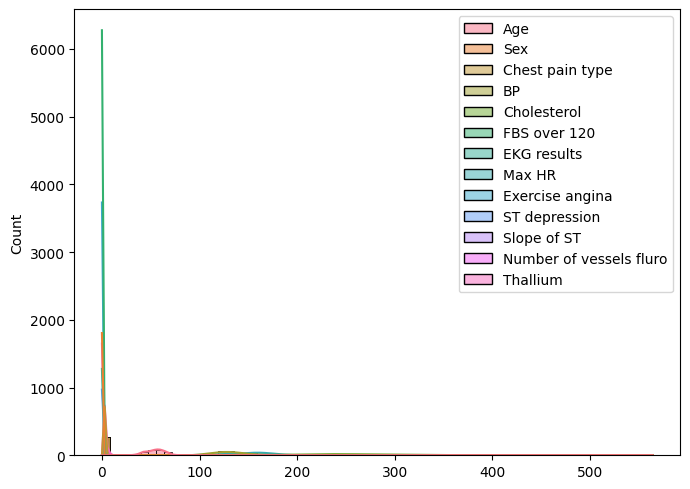

In [14]:


plt.figure(figsize=(7,5))
sns.histplot(hlt, kde=True, edgecolor='black')
plt.tight_layout()
plt.show()


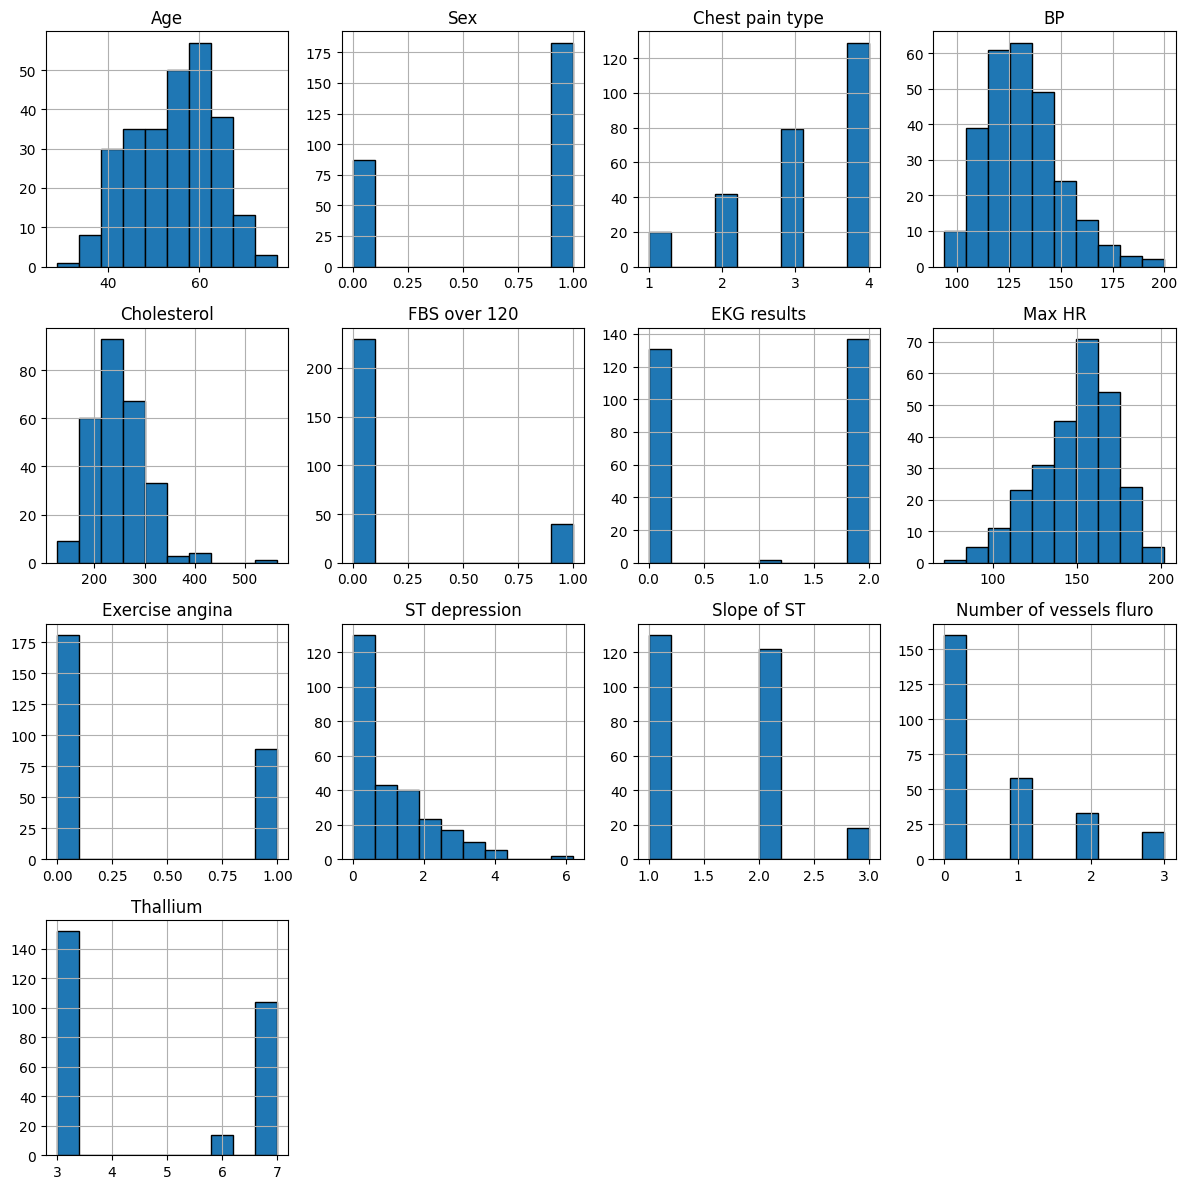

In [15]:
hlt.hist(figsize=(12, 12), edgecolor='black')
plt.tight_layout()
plt.show()


## 2. Boxplot 

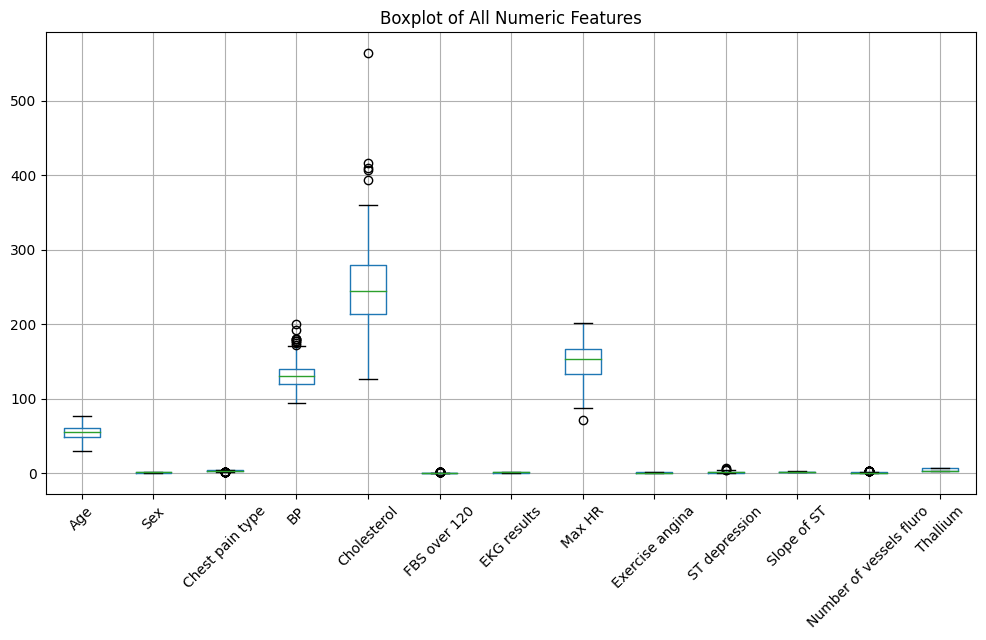

In [16]:
plt.figure(figsize=(12,6))
hlt.boxplot()
plt.xticks(rotation=45)
plt.title('Boxplot of All Numeric Features')
plt.show()


# 3.Countplot

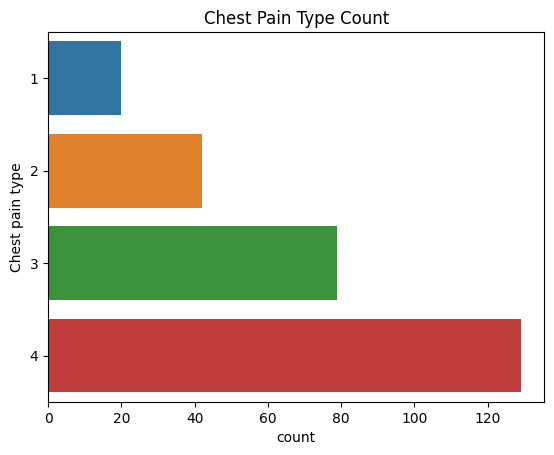

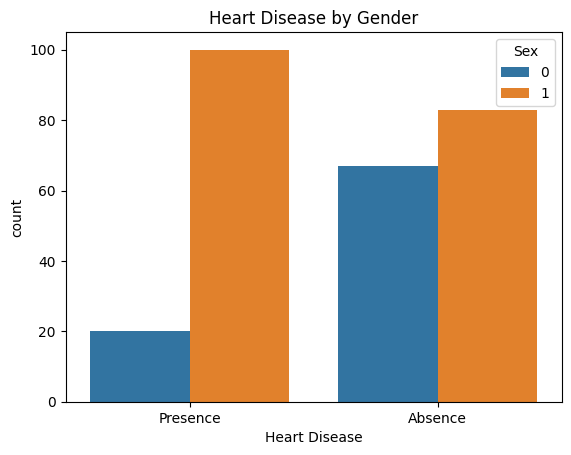

In [17]:
sns.countplot(y='Chest pain type', data=hlt)
plt.title('Chest Pain Type Count')
plt.show()

sns.countplot(x='Heart Disease', hue='Sex', data=hlt)
plt.title('Heart Disease by Gender')
plt.show()


# Explore Relationships

# 1. Matplotlib Scatter_plot

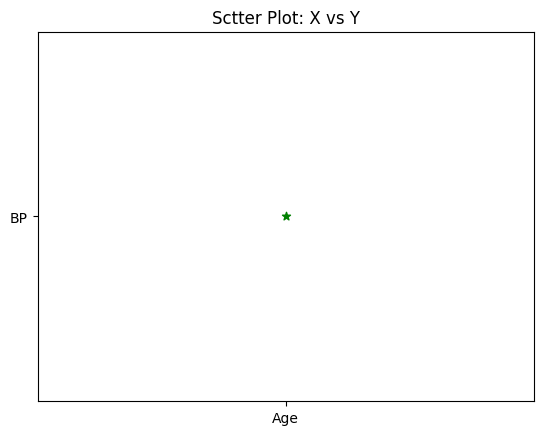

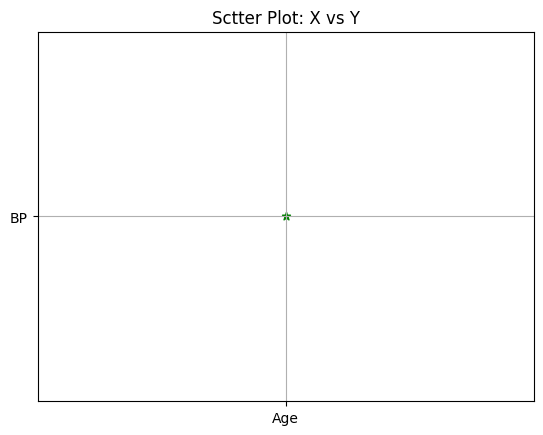

In [18]:
plt.scatter(x = "Age", y = "BP", color = "green", marker = "*")
plt.title("Sctter Plot: X vs Y")
#plt.xlabel("AGE")
#plt.ylabel("Blood_Perssure")
#plt.grid(True)
plt.show()

plt.scatter(x = "Age", y = "BP", color = "green", marker = "*")
plt.title("Sctter Plot: X vs Y")
#plt.xlabel("AGE")
#plt.ylabel("Blood_Perssure")
plt.grid(True)
plt.show()

# Seaborn Scatter plot 

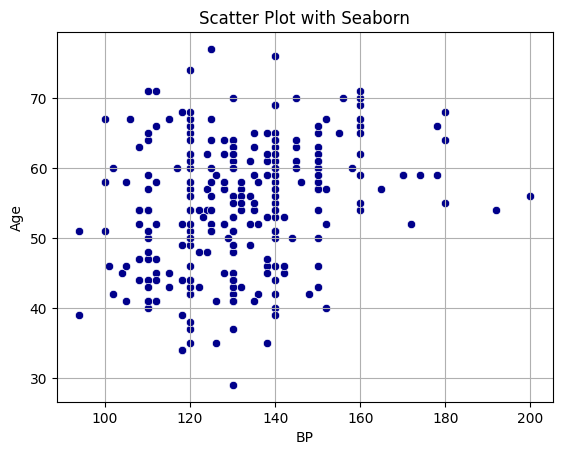

In [19]:
# Scatter plot
sns.scatterplot(x='BP', y='Age', data=hlt, color = "darkblue")
plt.title("Scatter Plot with Seaborn")
plt.grid(True)
plt.show()


# 2. Heatmap(Correlation)

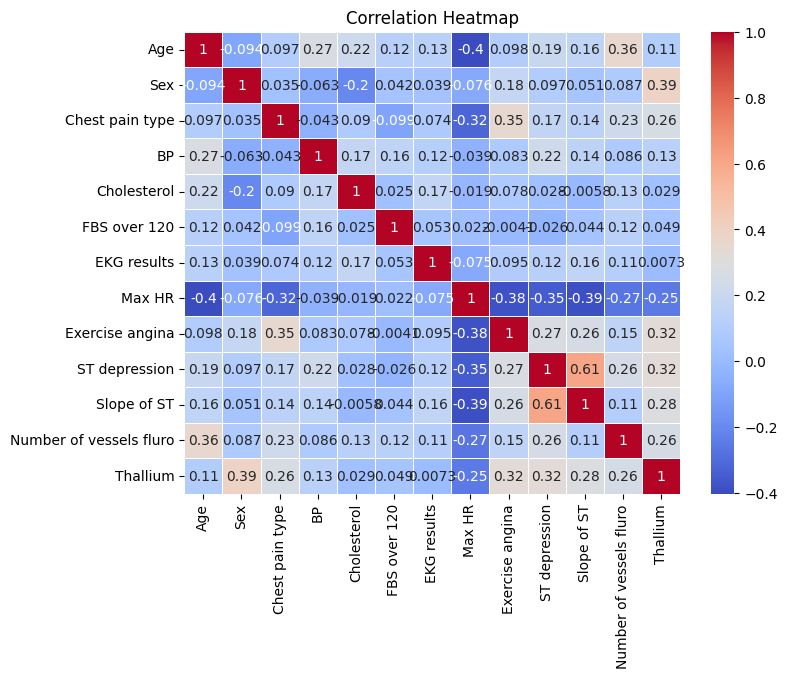

In [20]:
# just only numeric values
numeric_data = hlt.select_dtypes(include='number')

# Correlation matrix
corr = numeric_data.corr()

plt.figure(figsize=(8,6))
sns.heatmap(data=corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()